# Warehouse location and fleet forecasting

Workflow:
1. Extract data from the file with options
2. Plot a delivery point graph
3. Divide the delivery point into clusters (number of vehicles). Justify the choice of the number of vehicles
4. Analyze the initial partitioning into clusters in terms of vehicle capacity utilization
5. If necessary, exchange nodes between clusters and/or create new clusters
6. Analyze the result of the new partitioning
7. Solve traveling salesman problems for each cluster using a genetic algorithm
8. Analyze the resulting routes
9. Analyze transport utilization characteristics

## 1. Import Libraries and Data Loading

This section initializes the working environment, imports all required libraries, and loads the dataset for further analysis

In [1]:
import pandas as pd
from pandas import read_csv
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import math
from math import ceil
from functools import reduce
import random
from random import randint

In [2]:
data = read_csv('Retail_stores.csv', header = 0, index_col= 0)

## 2. Exploratory Data Analysis

This section explores the dataset to understand the spatial distribution of stores and their demand. Visualization helps identify natural groupings and assess whether clustering is appropriate.

In [3]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       200 non-null    float64
 1   Y       200 non-null    float64
 2   Demand  0 non-null      float64
 3   demand  200 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


,X,Y,Demand,demand
0,-10.564807,-8.261978,NaN,223
1,-14.391704,16.716745,NaN,337
2,1.675834,3.174182,NaN,216
3,11.187684,11.774094,NaN,97
4,6.833063,10.857710,NaN,351


In [4]:
del data['Demand']
data

,X,Y,demand
0,-10.564807,-8.261978,223
1,-14.391704,16.716745,337
2,1.675834,3.174182,216
3,11.187684,11.774094,97
4,6.833063,10.857710,351
...,...,...,...
195,-17.998140,14.449818,358
196,12.160333,4.299443,375
197,-13.561926,-6.276303,52
198,2.735801,-4.310057,251


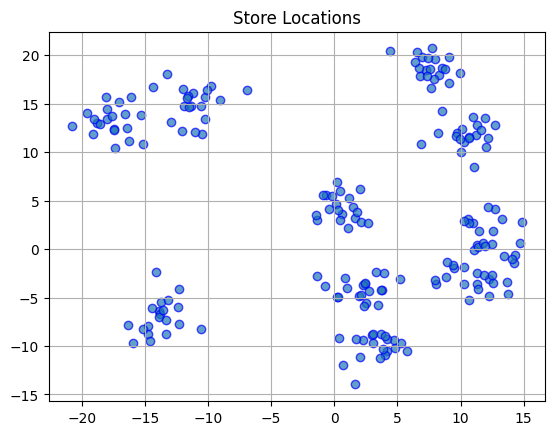

In [5]:
plt.scatter(data.iloc[:,0], data.iloc[:,1], alpha=0.7, edgecolors='b')

plt.title("Store Locations")
plt.grid(True)

plt.show()

## 3. Clustering and Logistics Calculations

In this section, KMeans clustering is applied to group stores into service regions. The number of clusters is selected based on vehicle capacity constraints.

The resulting clusters are evaluated in terms of capacity utilization to identify overloaded vehicles and assess feasibility of the initial solution.

In [6]:
# define truck capacity
capacity = 3000

# estimate required number of trucks (=clusters)
n_truck = ceil(sum(data.iloc[:, -1]) / capacity)
print('Due to the demand and the capacity of a truck the number of required clusters is', n_truck)

Due to the demand and the capacity of a truck the number of required clusters is 17


In [12]:
# apply KMeans clustering
kmeans_model = KMeans(n_clusters = n_truck)
kmeans = kmeans_model.fit(data.iloc[:, 0:2])

In [13]:
# add cluster labels to dataframe
df_data = data.copy()
df_data['Cluster'] = kmeans.labels_ + 1 

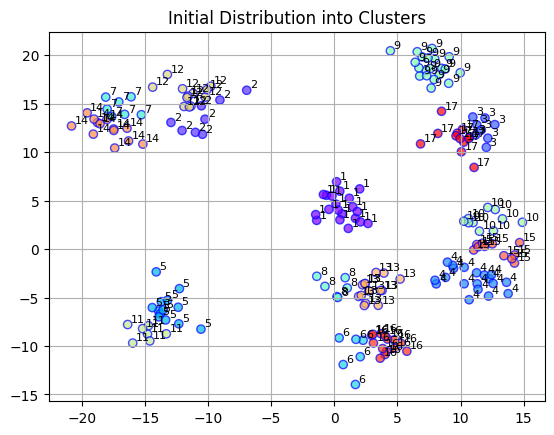

In [ ]:
# visualization of clusters
xes=list(df_data.iloc[:,0])
yes=list(df_data.iloc[:,1])
labels = list(df_data.iloc[:,-1])

plt.scatter(xes, yes, c = labels, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')
for i, txt in enumerate(labels):
    plt.annotate(txt, (xes[i] + 0.25, yes[i] + 0.25), fontsize = 8)

plt.title('Initial Distribution into Clusters')
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()

With this distribution, the carrying capacity of each of the 17 trucks will be:

In [36]:
cluster_demand = df_data.groupby('Cluster')['demand'].sum()
cap_after = capacity - cluster_demand

print(pd.DataFrame({'Initaial capacity': cap_after}))

         Initaial capacity
Cluster                   
1                    -1789
2                     1476
3                     1049
4                    -1372
5                     -478
6                     1912
7                     1389
8                     1227
9                    -2701
10                     324
11                    1634
12                     -81
13                     -71
14                    -348
15                     372
16                     228
17                     123


Looking at the initial clustering of points, the segmentation appears to be reasonably successful, as no clear outliers have emerged.

However, the table representing vehicle capacity utilization indicates negative results: some clusters require more transport capacity than is currently available.

This highlights that clustering based solely on spatial proximity is insufficient, as it does not guarantee feasibility under capacity constraints.

## 4. Constraint Handling via Cluster Reassignment and Hub Formation

To address capacity violations identified in the previous step, a reassignment strategy is introduced.

Clusters are grouped into delivery hubs, within which stores can be reassigned between clusters in order to balance demand. This localized redistribution aims to resolve capacity violations without drastically altering the overall spatial structure.

If no feasible reassignment is possible within a hub, a new cluster is created to ensure capacity constraints are satisfied.

In [25]:
# сopy dataframe to avoid modifying original data
df_reassign = df_data.copy()

# сonvert capacity difference to dictionary for easier updates
cluster_capacity = (capacity - df_reassign.groupby('Cluster')['demand'].sum()).to_dict()

In [26]:
# define hubs
hubs = [[5, 11], [1], [2, 7, 12, 14], [8, 13], [6, 16], [4, 10, 15], [3, 17], [9]] 

In [27]:
# add the column with hubs
df_reassign['Hub'] = None

for i in range(len(hubs)):
    for j in hubs[i]:
        df_reassign.loc[df_reassign['Cluster'] == j, 'Hub'] = i + 1

df_reassign

,X,Y,demand,Cluster,Hub
0,-10.564807,-8.261978,223,5,1
1,-14.391704,16.716745,337,12,3
2,1.675834,3.174182,216,1,2
3,11.187684,11.774094,97,3,7
4,6.833063,10.857710,351,17,7
...,...,...,...,...,...
195,-17.998140,14.449818,358,7,3
196,12.160333,4.299443,375,10,6
197,-13.561926,-6.276303,52,5,1
198,2.735801,-4.310057,251,13,4


In [38]:
# create a table that will contain the remaining carrying capacity for clusters
capacity_table = pd.DataFrame(data = None, columns=['Remain capacity'], index = list(range(1, n_truck + 1)))

In [39]:
# Reassignment logic
for hub in hubs:

    clusters = []
    remaining_capacity = []

    # Calculate remaining capacity per cluster
    for num in hub:
        used = df_reassign.loc[df_reassign['Cluster'] == num, 'demand'].sum()
        remaining_capacity.append(capacity - used)

    # Sort clusters by remaining capacity (ascending)
    pairs = sorted(zip(remaining_capacity, hub), key=lambda x: x[0])
    remaining_capacity, hub = zip(*pairs)
    remaining_capacity = list(remaining_capacity)
    hub = list(hub)

    # Check for overloaded clusters
    if any(capacity_value < 0 for capacity_value in remaining_capacity):
        overloaded_indices = [
            idx for idx, capacity_value in enumerate(remaining_capacity)
            if capacity_value < 0
        ]

        receiver_indices = [
            idx for idx, capacity_value in enumerate(remaining_capacity)
            if capacity_value >= 0
        ]

        # Sort receiver clusters by descending capacity
        if len(receiver_indices) > 1:
            good_pairs = sorted(
                zip(
                    remaining_capacity[receiver_indices[0]:],
                    hub[receiver_indices[0]:]
                ),
                key = lambda x: x[0],
                reverse = True
            )

            remaining_capacity = remaining_capacity[:overloaded_indices[-1] + 1]
            hub = hub[:overloaded_indices[-1] + 1]

            for val, cl in good_pairs:
                remaining_capacity.append(val)
                hub.append(cl)

        # If all clusters overloaded → create new cluster
        if len(overloaded_indices) == len(hub):
            new_cluster = df_reassign['Cluster'].max() + 1
            hub.append(new_cluster)
            receiver_indices.append(len(hub) - 1)
            remaining_capacity.append(capacity)

        # Reassign points
        for overloaded_idx in overloaded_indices:
            for receiver_idx in receiver_indices:
                while remaining_capacity[overloaded_idx] < 0:
                    demands = df_reassign.loc[df_reassign['Cluster'] == hub[overloaded_idx], 'demand']

                    if len(demands) == 0:
                        break

                    transfer_value = demands.min()

                    if remaining_capacity[receiver_idx] >= transfer_value:
                        remaining_capacity[overloaded_idx] += transfer_value
                        remaining_capacity[receiver_idx] -= transfer_value

                        idxs = df_reassign[
                            (df_reassign['demand'] == transfer_value) &
                            (df_reassign['Cluster'] == hub[overloaded_idx])
                        ].index

                        if len(idxs) == 0: 
                            break
                        df_reassign.loc[idxs[0], 'Cluster'] = hub[receiver_idx]

                    else: 
                        break

                if remaining_capacity[overloaded_idx] >= 0: 
                    break

                if (receiver_idx == receiver_indices[-1] and remaining_capacity[overloaded_idx] < 0):
                    new_cluster = df_reassign['Cluster'].max() + 1
                    hub.append(new_cluster)
                    receiver_indices.append(len(hub) - 1)
                    remaining_capacity.append(capacity)

    # Save results
    for idx in range(len(hub)):
        capacity_table.loc[hub[idx]] = remaining_capacity[idx]

In [40]:
# derive the resulting lifting capacity
capacity_table

,Remain capacity
1,222
2,923
3,1049
4,72
5,199
6,1912
7,1389
8,1143
9,110
10,69


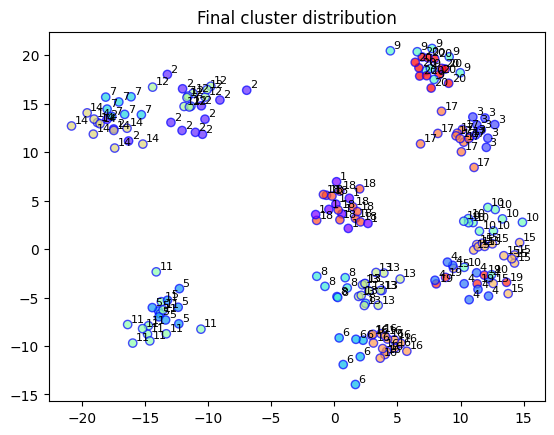

In [ ]:
# visualization of new clusters
xes_new = list(df_reassign.iloc[:, 0])
yes_new = list(df_reassign.iloc[:, 1])
labels_new = list(df_reassign.loc[:, 'Cluster'])
# с отвечает за лэйблы и их цвет
plt.scatter(xes_new, yes_new, c = labels_new, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')
# подписи к кластерам
for i, txt in enumerate(labels_new):
    plt.annotate(txt, (xes_new[i] + 0.25, yes_new[i] + 0.25), fontsize = 8)

plt.title('Final cluster distribution')
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()

The reassignment algorithm operates within predefined hubs and prioritizes balancing overloaded clusters.

Clusters are first sorted based on their remaining capacity, ensuring that the most overloaded clusters are processed first. Stores are then iteratively transferred from overloaded clusters to clusters with available capacity.

The algorithm prioritizes transferring stores with the smallest demand, allowing gradual balancing of cluster loads.

If no cluster within the hub can accommodate the excess demand, a new cluster is dynamically created. This ensures that capacity constraints are always satisfied.

While this approach effectively resolves capacity violations, it does not explicitly consider spatial distance during reassignment, which may lead to inefficient routing in later stages.

## 5. Vehicle Route Optimization via Genetic Algorithm

This section introduces depot locations based on spatial distribution of hubs. Multiple depots are defined to reduce transportation costs and balance routing load.

A genetic algorithm is implemented to solve the Traveling Salesman Problem for each cluster. The objective is to minimize route distance while ensuring all locations are visited.

### 5.1. Depot placement

Based on the spatial distribution of delivery hubs, a clear separation into two geographical regions can be observed: a left and a right cluster of centers.

To reduce total travel distance and improve routing efficiency, a multi-depot strategy is introduced. Instead of using a single origin point, two depots are defined:
- Depot 1 serves the left-side hubs (centers located at x < -5)
- Depot 2 serves the remaining hubs

Depot locations are estimated using the centroid (mean coordinates) of the associated hubs. This provides a simple yet effective approximation for depot placement without solving a dedicated facility location problem.

In [55]:
# calculate the centroids for hubs
hub_centroids = []
for hub in hubs:
    x_spis = []
    y_spis = []
    for clus in hub:
        x_coord = df_reassign.loc[df_reassign['Cluster'] == clus, 'X'].values.tolist()
        y_coord = df_reassign.loc[df_reassign['Cluster'] == clus, 'Y'].values.tolist()
        x_spis.extend(x_coord)
        y_spis.extend(y_coord)
    x_ = np.mean(x_spis)
    y_ = np.mean(y_spis)
    hub_centroids.append([x_, y_])

In [56]:
# calculate the coordinates of 1st and 2nd depots
left_hubs = [c for c in hub_centroids if c[0] < -5]
right_hubs = [c for c in hub_centroids if c[0] >= -5]

depot1 = [np.mean([c[0] for c in left_hubs]),
          np.mean([c[1] for c in left_hubs])]

depot2 = [np.mean([c[0] for c in right_hubs]),
          np.mean([c[1] for c in right_hubs])]

depots = [depot1, depot2]

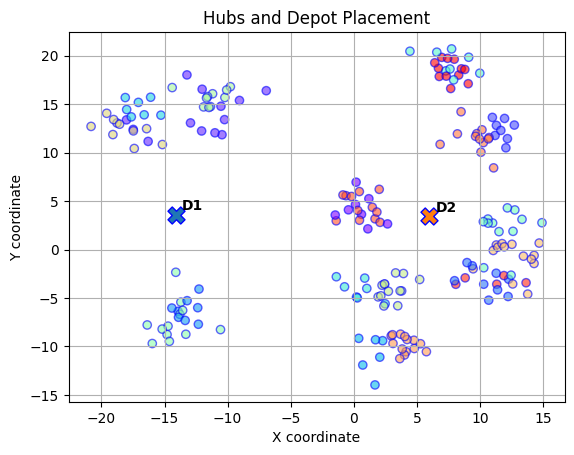

In [57]:
# visualization of Depots

# drawing of the stores
plt.scatter(df_reassign['X'], df_reassign['Y'], c = df_reassign['Cluster'], cmap = 'rainbow', alpha = 0.6, edgecolors = 'b')

# drawing of the depots
for i, depot in enumerate(depots):
    plt.scatter(depot[0], depot[1], marker = 'X', s = 150, edgecolor = 'b', label = f'Depot {i+1}')
    plt.text(depot[0] + 0.5, depot[1] + 0.5, f'D{i+1}', fontsize = 10, weight = 'bold')

plt.title("Hubs and Depot Placement")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()